# Transfer Learning with PyTorch — WikiArt

In this notebook we will:

1. **Build a custom PyTorch `Dataset`** from raw data stored in Parquet files (WikiArt images encoded as bytes).
2. **Apply transfer learning** using a pretrained **ResNet-18** to classify paintings by their **artist**.
3. Extend the approach to **multi-label / multi-head classification** — predicting artist, genre, and style simultaneously from the same image.

## What is transfer learning?

Transfer learning is the practice of taking a model that has already been trained on a large dataset (here, ImageNet with ~1.2M images and 1000 classes) and **reusing its learned features** for a new task. This is extremely useful when:

- Our dataset is relatively small (compared to ImageNet),
- Training a deep network from scratch would take too long or overfit,
- The low-level visual features (edges, textures, shapes) transfer well to our domain.

There are two common strategies:

| Strategy | What we change | When to use |
|---|---|---|
| **Feature extraction** | Freeze all backbone layers, only train the new classification head | Small dataset, limited compute |
| **Fine-tuning** | Let all layers update, but initialize from pretrained weights | Larger / more specialized dataset |

We will see both in action.

## Dataset

We use a subset of the [WikiArt dataset](https://huggingface.co/datasets/huggan/wikiart) — paintings labeled with artist, genre, and style. The raw data comes in Parquet files where each row contains the image bytes plus integer labels.

## 1. Setup — imports, device, reproducibility

In [2]:
import io
import json
import time

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split

# Pick the best available device. CUDA > MPS (Apple Silicon) > CPU.
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: mps


## 2. Load raw data from Parquet files

Parquet is a columnar storage format — efficient for large tabular data. Here each row of the Parquet file contains:

- `image` — a dictionary `{"bytes": <raw image bytes>, "path": ...}`
- `artist`, `genre`, `style` — integer indices into a label vocabulary

We load several shards and concatenate them into a single `pandas.DataFrame`.

In [3]:
# Reference: https://huggingface.co/datasets/huggan/wikiart/tree/main/data
parquet_files = [
    "./data/train-00000-of-00072.parquet",
    "./data/train-00001-of-00072.parquet",
    "./data/train-00002-of-00072.parquet",
]

df_dataset = pd.concat(
    [pq.read_table(p).to_pandas() for p in parquet_files],
    ignore_index=True,
)
print(f"Loaded {len(df_dataset)} samples")
df_dataset.head()

Loaded 3396 samples


,image,artist,genre,style
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,22,4,21
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,20,7,4
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,16,6,20
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,17,2,12
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,9,10,23


### Label vocabularies

The Parquet files only store integer label IDs. Human-readable names live in a separate `dataset_infos.json` file. We load them so we can map numeric predictions back to artist / genre / style names.

In [4]:
with open("./data/dataset_infos.json", "r") as f:
    dataset_info = json.load(f)

artists = dataset_info["huggan--wikiart"]["features"]["artist"]["names"]
genres  = dataset_info["huggan--wikiart"]["features"]["genre"]["names"]
styles  = dataset_info["huggan--wikiart"]["features"]["style"]["names"]

print(f"Num artists: {len(artists)}")
print(f"Num genres:  {len(genres)}")
print(f"Num styles:  {len(styles)}")

Num artists: 129
Num genres:  11
Num styles:  27


### Peek at one sample — decode bytes back into an image

Artist: vincent-van-gogh
Genre:  landscape
Style:  Realism
Original size: (750, 597)


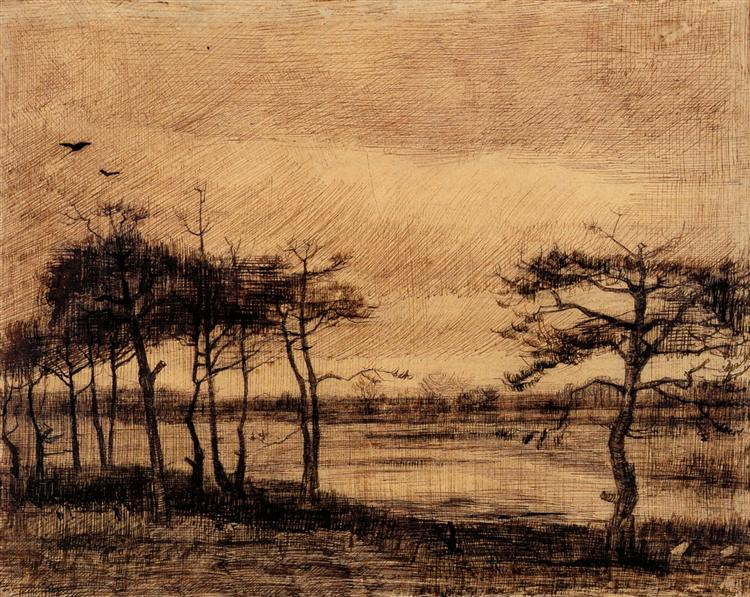

In [5]:
sample_idx = 0
image = Image.open(io.BytesIO(df_dataset["image"][sample_idx]["bytes"]))

print(f"Artist: {artists[df_dataset['artist'][sample_idx]]}")
print(f"Genre:  {genres[df_dataset['genre'][sample_idx]]}")
print(f"Style:  {styles[df_dataset['style'][sample_idx]]}")
print(f"Original size: {image.size}")
image

## 3. Remap labels to contiguous indices

We only loaded a few shards, so not every artist / genre / style from the full vocabulary is present in our subset. For a classifier with `N` output neurons we need labels in the range `[0, N-1]` with no gaps.

For each target column we:
1. Count the occurrences of each original label,
2. Assign a new contiguous index (`new_<target>_label`),
3. Keep the human-readable name so we can display predictions later.

In [6]:
def remap_labels(df, column, name_vocab):
    """Create a DataFrame mapping old label ids to contiguous new ids.

    Returns a DataFrame with columns:
        - <column>            : original integer id
        - count               : number of samples with that label in df
        - new_<column>_label  : contiguous index in [0, N-1]
        - <column>_name       : human-readable name
    """
    mapping = (
        df[column]
        .value_counts()
        .reset_index()
        .reset_index(names=f"new_{column}_label")
    )
    mapping[f"{column}_name"] = mapping[column].apply(lambda x: name_vocab[x])
    return mapping

artist_map = remap_labels(df_dataset, "artist", artists)
genre_map  = remap_labels(df_dataset, "genre",  genres)
style_map  = remap_labels(df_dataset, "style",  styles)

print(f"Artists in subset: {len(artist_map)}")
print(f"Genres in subset:  {len(genre_map)}")
print(f"Styles in subset:  {len(style_map)}")
artist_map.head()

Artists in subset: 24
Genres in subset:  11
Styles in subset:  16


,new_artist_label,artist,count,artist_name
0,0,22,339,vincent-van-gogh
1,1,14,328,nicholas-roerich
2,2,17,249,pierre-auguste-renoir
3,3,4,220,claude-monet
4,4,18,179,pyotr-konchalovsky


In [7]:
# Merge the new label columns back into the main dataframe
df_labeled = (
    df_dataset
    .merge(artist_map[["artist", "new_artist_label"]], on="artist", how="left")
    .merge(genre_map[["genre",   "new_genre_label"]],  on="genre",  how="left")
    .merge(style_map[["style",   "new_style_label"]],  on="style",  how="left")
)
df_labeled.head()

,image,artist,genre,style,new_artist_label,new_genre_label,new_style_label
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,22,4,21,0,0,1
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,20,7,4,8,6,8
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,16,6,20,13,1,2
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,17,2,12,2,3,0
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,9,10,23,19,2,3


## 4. Build a custom `Dataset` from scratch

PyTorch expects training data to come from an object implementing three methods:

- `__init__`  — set up references to data / labels / transforms
- `__len__`   — total number of samples
- `__getitem__(idx)` — return the `idx`-th sample as `(input, label)`

Everything else (batching, shuffling, parallel loading) is handled by `DataLoader`.

Our dataset:
- Reads image bytes from the DataFrame and decodes them with PIL on-the-fly (cheap memory),
- Applies an image transform (resize, tensorize),
- Supports any target column (`new_artist_label`, `new_genre_label`, `multilabels`, ...).

In [8]:
class WikiArtDataset(Dataset):
    """In-memory dataset of WikiArt images stored as raw bytes in a DataFrame.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain an 'image' column whose values are dicts {"bytes": <bytes>, ...},
        and the column specified by `target_name`.
    target_name : str
        Name of the column to use as label.
    transform : callable, optional
        Image transform (e.g. torchvision.transforms.Compose).
    target_transform : callable, optional
        Transform applied to the label (e.g. wrap in a tensor).
    """

    def __init__(self, df, target_name, transform=None, target_transform=None):
        # reset_index so positional indexing (iloc-style) always works after splits
        self.labels = df[target_name].reset_index(drop=True)
        self.image_bytes = df["image"].reset_index(drop=True)
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Decode the image on demand — keeps the dataset lightweight in memory
        image = Image.open(io.BytesIO(self.image_bytes[idx]["bytes"])).convert("RGB")
        label = self.labels[idx]

        if self.transform is not None:
            image = self.transform(image)
        if self.target_transform is not None:
            label = self.target_transform(label)
        return image, label

## 5. Transforms and a first DataLoader

ResNet-18 was trained on **224×224** RGB images normalized with ImageNet statistics, so we follow the same recipe. `transforms.Compose` chains image operations into a single callable.

Feature batch shape: torch.Size([8, 3, 224, 224])   # (batch, channels, H, W)
Labels  batch shape: torch.Size([8])
First label: 5 -> camille-pissarro


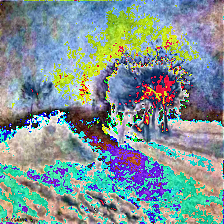

In [ ]:
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

data_transforms_demo = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# First sanity-check dataset — no train/val split yet
demo_dataset = WikiArtDataset(df_labeled, target_name="new_artist_label", transform=data_transforms_demo)
demo_loader  = DataLoader(demo_dataset, batch_size=8, shuffle=True)

features, labels = next(iter(demo_loader))
print(f"Feature batch shape: {features.shape}   # (batch, channels, H, W)")
print(f"Labels  batch shape: {labels.shape}")
print(f"First label: {labels[0].item()} -> {artist_map.loc[artist_map['new_artist_label'] == labels[0].item(), 'artist_name'].values[0]}")
transforms.ToPILImage()(features[0])

## 6. Train / validation split

We use `train_test_split` on the sample **indices**, then feed those indices to `SubsetRandomSampler`. The advantage of this pattern over building two separate `Dataset` objects is that we only keep one copy of the underlying data in memory — the two `DataLoader`s just read different slices of it.

In [10]:
train_idx, valid_idx = train_test_split(
    np.arange(len(df_labeled)),
    test_size=0.2,
    shuffle=True,
    random_state=42,
)

print(f"Train samples: {len(train_idx)}")
print(f"Val   samples: {len(valid_idx)}")

Train samples: 2716
Val   samples: 680


## 7. Transfer learning — single label (artist)

### 7.1 Assemble the DataLoaders

In [11]:
BATCH_SIZE = 32

dataset_artist = WikiArtDataset(
    df_labeled,
    target_name="new_artist_label",
    transform=data_transforms,
)

train_loader = DataLoader(dataset_artist, batch_size=BATCH_SIZE, sampler=SubsetRandomSampler(train_idx))
valid_loader = DataLoader(dataset_artist, batch_size=BATCH_SIZE, sampler=SubsetRandomSampler(valid_idx))

dataloaders  = {"train": train_loader, "val": valid_loader}
dataset_lens = {"train": len(train_idx), "val": len(valid_idx)}

### 7.2 Build the model — pretrained ResNet-18 with a new head

Key idea: **keep the ResNet backbone, replace only the final linear layer** so that its output size matches our number of artists.

- `model.fc` in ResNet is `Linear(512 -> 1000)` (the 1000 ImageNet classes).
- We swap it for `Linear(512 -> num_artists)` initialized randomly — this is the only layer that starts from zero knowledge.

The commented-out freezing block shows how to switch from **fine-tuning** (all layers learn) to **feature extraction** (only the head learns). Feature extraction trains much faster but usually caps at a lower accuracy.

In [12]:
num_artists = len(artist_map)

# Load ImageNet-pretrained weights. `ResNet18_Weights.DEFAULT` is the
# modern replacement for the deprecated `pretrained=True` argument.
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# --- Optional: freeze the backbone for pure feature extraction ---
# for param in model.parameters():
#     param.requires_grad = False

# Replace the classification head
num_features = model.fc.in_features
model.fc = torch.nn.Linear(num_features, num_artists)
model = model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Count trainable vs frozen parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print(f"Trainable parameters: {trainable:,}")
print(f"Frozen parameters:    {frozen:,}")

Trainable parameters: 11,188,824
Frozen parameters:    0


### 7.3 Training loop

The loop follows the standard **train / validation** pattern:

1. For each epoch, iterate through both phases.
2. In the **train** phase: enable gradients, compute loss, backprop, step.
3. In the **val** phase: disable gradients (via `torch.set_grad_enabled(False)`) and only accumulate metrics.
4. Save a checkpoint after each validation pass so we can resume / compare.

We also track **per-epoch time** and **total training time** — useful both for profiling and for helping students build intuition about how expensive training really is.

In [13]:
def train_single_label(model, criterion, optimizer, dataloaders, dataset_lens,
                       num_epochs=3, checkpoint_prefix="resnet18_artist"):
    """Standard train/val loop for a single-label classification head."""
    total_start = time.time()

    for epoch in range(num_epochs):
        print(f"\n--- Epoch {epoch + 1}/{num_epochs} ---")
        epoch_start = time.time()

        for phase in ["train", "val"]:
            model.train() if phase == "train" else model.eval()

            running_loss = 0.0
            running_correct = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, dim=1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss    += loss.item() * inputs.size(0)
                running_correct += torch.sum(preds == labels).item()

            epoch_loss = running_loss    / dataset_lens[phase]
            epoch_acc  = running_correct / dataset_lens[phase]
            print(f"  {phase:5s} loss: {epoch_loss:.4f}   acc: {epoch_acc:.4f}")

            # Save checkpoint after validation so we always keep the metrics
            # we just printed paired with the saved weights.
            if phase == "val":
                path = f"./data/{checkpoint_prefix}_epoch_{epoch + 1}.pth"
                torch.save(model.state_dict(), path)

        print(f"  epoch time: {time.time() - epoch_start:.1f}s")

    print(f"\nTotal training time: {time.time() - total_start:.1f}s")

In [14]:
NUM_EPOCHS = 10
train_single_label(model, criterion, optimizer, dataloaders, dataset_lens, num_epochs=NUM_EPOCHS)


--- Epoch 1/10 ---
  train loss: 2.2088   acc: 0.3608
  val   loss: 2.3397   acc: 0.3691
  epoch time: 55.9s

--- Epoch 2/10 ---
  train loss: 1.5645   acc: 0.5306
  val   loss: 2.5509   acc: 0.3882
  epoch time: 46.7s

--- Epoch 3/10 ---
  train loss: 1.2601   acc: 0.6197
  val   loss: 3.2504   acc: 0.3647
  epoch time: 47.2s

--- Epoch 4/10 ---
  train loss: 0.9531   acc: 0.6951
  val   loss: 2.4614   acc: 0.4647
  epoch time: 46.9s

--- Epoch 5/10 ---
  train loss: 0.6196   acc: 0.8141
  val   loss: 3.0480   acc: 0.4382
  epoch time: 47.0s

--- Epoch 6/10 ---
  train loss: 0.4661   acc: 0.8546
  val   loss: 1.9050   acc: 0.5338
  epoch time: 46.9s

--- Epoch 7/10 ---
  train loss: 0.2764   acc: 0.9146
  val   loss: 2.1491   acc: 0.5441
  epoch time: 47.1s

--- Epoch 8/10 ---
  train loss: 0.1991   acc: 0.9415
  val   loss: 2.2385   acc: 0.5265
  epoch time: 47.4s

--- Epoch 9/10 ---
  train loss: 0.1615   acc: 0.9518
  val   loss: 1.9901   acc: 0.5676
  epoch time: 47.3s

--- Epoch

## 8. Inference — predicting the artist of a new painting

### 8.1 Reload a saved checkpoint

In a real workflow you would train once and then re-use the saved weights many times. This cell shows how to rebuild the exact same architecture and load saved weights into it.

In [15]:
# Rebuild an untrained ResNet-18 with the same head size, then load saved weights.
model_for_inference = models.resnet18(weights=None)
model_for_inference.fc = torch.nn.Linear(model_for_inference.fc.in_features, num_artists)
model_for_inference = model_for_inference.to(device)

checkpoint_path = "./data/resnet18_artist_epoch_10.pth"
# `weights_only=True` is the safe mode for loading untrusted files.
model_for_inference.load_state_dict(
    torch.load(checkpoint_path, weights_only=True, map_location=device)
)
model_for_inference.eval();

### 8.2 End-to-end prediction pipeline

In [16]:
def predict(model, image_path, device=device, input_size=(224, 224)):
    """Run a single image through the model and return class probabilities.

    Parameters
    ----------
    model : nn.Module
        A trained model whose output dim matches the vocabulary of interest.
    image_path : str
        Path to a local image file (any PIL-readable format).
    device : torch.device
    input_size : (H, W), default (224, 224)

    Returns
    -------
    probs : Tensor of shape (num_classes,)   # softmax probabilities
    logits : Tensor of shape (num_classes,)  # raw pre-softmax outputs
    """
    preprocess = transforms.Compose([
        transforms.Resize(input_size),
        transforms.ToTensor(),
    ])

    image = Image.open(image_path).convert("RGB")
    x = preprocess(image).unsqueeze(0).to(device)  # add batch dim -> (1, 3, H, W)

    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs  = torch.nn.functional.softmax(logits[0], dim=0)
    return probs, logits[0]

In [17]:
probs, _ = predict(model_for_inference, "./data/beach-monet.png")

# Top-1
top_idx = torch.argmax(probs).item()
top_name = artist_map.loc[artist_map["new_artist_label"] == top_idx, "artist_name"].values[0]
print(f"Top-1 prediction: {top_name} ({probs[top_idx] * 100:.2f}%)")

# Top-5
values, indices = torch.topk(probs, k=5)
print("\nTop-5 predictions:")
for p, i in zip(values.tolist(), indices.tolist()):
    name = artist_map.loc[artist_map["new_artist_label"] == i, "artist_name"].values[0]
    print(f"  {p * 100:5.2f}%  -  {name}")

Top-1 prediction: ivan-aivazovsky (94.85%)

Top-5 predictions:
  94.85%  -  ivan-aivazovsky
   1.29%  -  rembrandt
   1.21%  -  ivan-shishkin
   0.96%  -  nicholas-roerich
   0.53%  -  claude-monet


## 9. Multi-label classification

So far we have predicted **one target** (artist). But each painting in WikiArt has **three** labels: artist, genre, and style. Instead of training three separate models we can train a single network that produces three predictions at once.

### Two flavors of "multi-label"

1. **Multiple labels for multiple objects in one image** — e.g. a photo that contains a dog, a frisbee, and grass. These labels are typically *independent*, and the output uses a sigmoid per class.

   ![multilabel-1](./images/multilabel.png)

2. **Multiple labels forming a hierarchy for a single object** — e.g. a painting is by *Monet* (artist) who paints *landscapes* (genre) in the *Impressionist* (style). The labels describe *the same object* but at different levels of abstraction.

   <img src="./images/multilabel-jerarquia.png" alt="multilabel hierarchy" width="500"/>

We will implement case 2: a shared backbone with **three independent classification heads**, one per target. Each head uses softmax + cross-entropy (since the labels within each target are mutually exclusive — a painting has exactly one artist).

### 9.1 Multi-head architecture

In [18]:
class MultiHeadResNet(torch.nn.Module):
    """ResNet backbone with three independent classification heads.

    The pretrained ResNet's `.fc` layer is replaced with `nn.Identity()` so that
    the backbone outputs its 512-dim feature vector directly. We then attach
    three parallel `Linear` heads on top of those features.

    Parameters
    ----------
    backbone : nn.Module
        A torchvision ResNet whose `.fc` attribute will be replaced.
    head_sizes : sequence of int
        Number of output classes for each head, in order
        (artist_classes, genre_classes, style_classes).
    """

    def __init__(self, backbone, head_sizes):
        super().__init__()
        num_features = backbone.fc.in_features
        backbone.fc = torch.nn.Identity()  # the backbone now outputs 512-dim features
        self.backbone = backbone

        self.head_artist = torch.nn.Linear(num_features, head_sizes[0])
        self.head_genre  = torch.nn.Linear(num_features, head_sizes[1])
        self.head_style  = torch.nn.Linear(num_features, head_sizes[2])

    def forward(self, x):
        features = self.backbone(x)           # (B, 512)
        return (
            self.head_artist(features),       # (B, num_artists)
            self.head_genre(features),        # (B, num_genres)
            self.head_style(features),        # (B, num_styles)
        )

### 9.2 Dataset with a multi-label target

We add a `multilabels` column — a list `[artist_id, genre_id, style_id]` per sample — and tell the dataset to wrap it in a `torch.int64` tensor so a batch becomes a `(B, 3)` tensor.

In [19]:
df_multi = df_labeled.copy()
df_multi["multilabels"] = df_multi[["new_artist_label", "new_genre_label", "new_style_label"]].values.tolist()
df_multi.head()

,image,artist,genre,style,new_artist_label,new_genre_label,new_style_label,multilabels
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,22,4,21,0,0,1,"[0, 0, 1]"
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,20,7,4,8,6,8,"[8, 6, 8]"
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,16,6,20,13,1,2,"[13, 1, 2]"
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,17,2,12,2,3,0,"[2, 3, 0]"
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,9,10,23,19,2,3,"[19, 2, 3]"


In [20]:
dataset_multi = WikiArtDataset(
    df_multi,
    target_name="multilabels",
    transform=data_transforms,
    target_transform=lambda x: torch.tensor(x, dtype=torch.int64),
)

train_loader_multi = DataLoader(dataset_multi, batch_size=BATCH_SIZE, sampler=SubsetRandomSampler(train_idx))
valid_loader_multi = DataLoader(dataset_multi, batch_size=BATCH_SIZE, sampler=SubsetRandomSampler(valid_idx))

dataloaders_multi  = {"train": train_loader_multi, "val": valid_loader_multi}

# Quick shape sanity-check
features, labels = next(iter(train_loader_multi))
print(f"Feature batch shape: {features.shape}")
print(f"Labels  batch shape: {labels.shape}   # (B, 3) -> [artist, genre, style]")
print(f"First label row: {labels[0].tolist()}")

Feature batch shape: torch.Size([32, 3, 224, 224])
Labels  batch shape: torch.Size([32, 3])   # (B, 3) -> [artist, genre, style]
First label row: [7, 9, 7]


### 9.3 Instantiate the multi-head model

In [21]:
head_sizes = [len(artist_map), len(genre_map), len(style_map)]
print(f"Head sizes (artist / genre / style): {head_sizes}")

backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
multi_model = MultiHeadResNet(backbone, head_sizes).to(device)

# One loss per head — all cross-entropy since each head is single-label (one-hot)
criterion_artist = torch.nn.CrossEntropyLoss()
criterion_genre  = torch.nn.CrossEntropyLoss()
criterion_style  = torch.nn.CrossEntropyLoss()

multi_optimizer = torch.optim.Adam(multi_model.parameters(), lr=1e-3)

Head sizes (artist / genre / style): [24, 11, 16]


### 9.4 Multi-head training loop

The key difference from single-label training:

- The model returns **three logits tensors** per forward pass.
- We compute **three losses** and sum them into a single `loss_total` for backprop.
  Summing means every head contributes equally to the gradient; you could also weight them (`α·loss_a + β·loss_g + γ·loss_s`) if one target is more important.
- We track accuracy for each head independently so we can see which targets are easy / hard.

In [22]:
def train_multi_head(model, criterions, optimizer, dataloaders, dataset_lens,
                     num_epochs=3, checkpoint_prefix="resnet18_multihead"):
    """Train/val loop for a model with three classification heads.

    Parameters
    ----------
    criterions : tuple of 3 loss functions -> (artist, genre, style)
    """
    crit_artist, crit_genre, crit_style = criterions
    total_start = time.time()

    for epoch in range(num_epochs):
        print(f"\n--- Epoch {epoch + 1}/{num_epochs} ---")
        epoch_start = time.time()

        for phase in ["train", "val"]:
            model.train() if phase == "train" else model.eval()

            losses    = {"artist": 0.0, "genre": 0.0, "style": 0.0}
            corrects  = {"artist": 0,   "genre": 0,   "style": 0}

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)               # (B, 3)
                y_artist, y_genre, y_style = labels[:, 0], labels[:, 1], labels[:, 2]

                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == "train"):
                    out_artist, out_genre, out_style = model(inputs)

                    loss_artist = crit_artist(out_artist, y_artist)
                    loss_genre  = crit_genre(out_genre,   y_genre)
                    loss_style  = crit_style(out_style,   y_style)
                    loss_total  = loss_artist + loss_genre + loss_style

                    if phase == "train":
                        loss_total.backward()
                        optimizer.step()

                bs = inputs.size(0)
                losses["artist"]   += loss_artist.item() * bs
                losses["genre"]    += loss_genre.item()  * bs
                losses["style"]    += loss_style.item()  * bs
                corrects["artist"] += torch.sum(torch.argmax(out_artist, 1) == y_artist).item()
                corrects["genre"]  += torch.sum(torch.argmax(out_genre,  1) == y_genre).item()
                corrects["style"]  += torch.sum(torch.argmax(out_style,  1) == y_style).item()

            n = dataset_lens[phase]
            print(f"  {phase}:")
            for head in ["artist", "genre", "style"]:
                print(f"    {head:6s} loss: {losses[head] / n:.4f}   acc: {corrects[head] / n:.4f}")

            if phase == "val":
                torch.save(model.state_dict(), f"./data/{checkpoint_prefix}_epoch_{epoch + 1}.pth")

        print(f"  epoch time: {time.time() - epoch_start:.1f}s")

    print(f"\nTotal training time: {time.time() - total_start:.1f}s")

In [23]:
NUM_EPOCHS_MULTI = 10
train_multi_head(
    multi_model,
    (criterion_artist, criterion_genre, criterion_style),
    multi_optimizer,
    dataloaders_multi,
    dataset_lens,
    num_epochs=NUM_EPOCHS_MULTI,
)


--- Epoch 1/10 ---
  train:
    artist loss: 2.1727   acc: 0.3800
    genre  loss: 1.6008   acc: 0.4440
    style  loss: 1.5637   acc: 0.5018
  val:
    artist loss: 3.1203   acc: 0.3294
    genre  loss: 2.2264   acc: 0.3765
    style  loss: 2.0743   acc: 0.4897
  epoch time: 49.0s

--- Epoch 2/10 ---
  train:
    artist loss: 1.5796   acc: 0.5243
    genre  loss: 1.2684   acc: 0.5619
    style  loss: 1.1909   acc: 0.6116
  val:
    artist loss: 2.4460   acc: 0.3926
    genre  loss: 2.1882   acc: 0.4176
    style  loss: 1.5594   acc: 0.5294
  epoch time: 47.7s

--- Epoch 3/10 ---
  train:
    artist loss: 1.1837   acc: 0.6425
    genre  loss: 1.0928   acc: 0.6200
    style  loss: 0.9318   acc: 0.6973
  val:
    artist loss: 1.7708   acc: 0.4809
    genre  loss: 1.3915   acc: 0.5515
    style  loss: 1.3137   acc: 0.5765
  epoch time: 46.5s

--- Epoch 4/10 ---
  train:
    artist loss: 0.9518   acc: 0.7018
    genre  loss: 0.9631   acc: 0.6661
    style  loss: 0.7734   acc: 0.7390
  val

## 10. Key takeaways

- **Transfer learning** lets us reuse features learned on a massive dataset (ImageNet) for a much smaller, more specialized task (WikiArt). The only randomly-initialized part is the new classification head.
- A **custom `Dataset`** is just three methods (`__init__`, `__len__`, `__getitem__`). Everything else — batching, shuffling, parallel loading — comes for free from `DataLoader`.
- **`SubsetRandomSampler`** is a clean way to get a train/val split without duplicating the underlying data.
- For **multi-head / multi-label hierarchical** problems, a shared backbone with multiple heads trained with a **sum of losses** is a strong and simple baseline.

### Things to try next

- Freeze the backbone (`param.requires_grad = False`) and compare accuracy and training time against full fine-tuning.
- Add data augmentation (`RandomHorizontalFlip`, `ColorJitter`, `RandomCrop`) to the training transform and see how it affects generalization.
- Swap ResNet-18 for a larger backbone (ResNet-50, EfficientNet) and compare.
- Weight the three losses unequally and observe how the per-head accuracies shift.